In [1]:
# Cai dat thu vien can thiet
%pip install -q -U ultralytics


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 3.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import va kiem tra moi truong
from pathlib import Path
from collections import Counter
from concurrent.futures import ThreadPoolExecutor
import json
import math
import os
import random
import shutil
import time
import zipfile

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from PIL import Image
from tqdm.auto import tqdm
from ultralytics import YOLO
import ultralytics

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("PyTorch:", torch.__version__)
print("Ultralytics:", ultralytics.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: Bat GPU Accelerator tren Kaggle truoc khi fine-tune full dataset.")


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
PyTorch: 2.10.0+cu128
Ultralytics: 8.4.137
CUDA available: True
GPU: Tesla T4


## 1. Tim va chuan bi dataset


In [3]:
# Tim dataset va tao ban writable neu can
WORK_DATA_PARENT = Path("/kaggle/working/dataset")
PREFERRED_ROOT = WORK_DATA_PARENT / "bdd100k-yolo"
INPUT_ROOT = Path("/kaggle/input")


def is_valid_bdd_root(root: Path) -> bool:
    return (
        (root / "data.yaml").exists()
        and (root / "train" / "images").exists()
        and (root / "train" / "labels").exists()
        and (root / "val" / "images").exists()
        and (root / "val" / "labels").exists()
    )


def copy_to_writable_root(src_root: Path, dst_root: Path) -> Path:
    # Copy label va yaml, dung symlink cho anh de tranh copy hang GB du lieu
    if dst_root.exists() and is_valid_bdd_root(dst_root):
        return dst_root

    dst_root.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src_root / "data.yaml", dst_root / "data.yaml")

    for split in ["train", "val", "test"]:
        src_split = src_root / split
        if not src_split.exists():
            continue

        dst_split = dst_root / split
        dst_split.mkdir(parents=True, exist_ok=True)

        src_images = src_split / "images"
        dst_images = dst_split / "images"
        if src_images.exists() and not dst_images.exists():
            dst_images.symlink_to(src_images, target_is_directory=True)

        src_labels = src_split / "labels"
        dst_labels = dst_split / "labels"
        if src_labels.exists() and not dst_labels.exists():
            shutil.copytree(src_labels, dst_labels)

    return dst_root


if is_valid_bdd_root(PREFERRED_ROOT):
    DATA_ROOT = PREFERRED_ROOT
else:
    candidates = []
    if INPUT_ROOT.exists():
        for yml in INPUT_ROOT.rglob("data.yaml"):
            root = yml.parent
            if "bdd100k" in str(root).lower() and is_valid_bdd_root(root):
                candidates.append(root)

    if candidates:
        DATA_ROOT = copy_to_writable_root(candidates[0], PREFERRED_ROOT)
    else:
        zip_candidates = []
        if INPUT_ROOT.exists():
            zip_candidates = [p for p in INPUT_ROOT.rglob("*.zip") if "bdd" in str(p).lower() or "yolo" in str(p).lower()]

        extracted = False
        WORK_DATA_PARENT.mkdir(parents=True, exist_ok=True)

        for zip_path in zip_candidates:
            try:
                with zipfile.ZipFile(zip_path, "r") as zf:
                    names = zf.namelist()
                    has_bdd = any("bdd100k-yolo" in name.lower() for name in names)
                    if has_bdd:
                        print("Extract:", zip_path)
                        zf.extractall(WORK_DATA_PARENT)
                        extracted = True
                        break
            except zipfile.BadZipFile:
                pass

        if not extracted or not is_valid_bdd_root(PREFERRED_ROOT):
            found = [p.parent for p in WORK_DATA_PARENT.rglob("data.yaml") if is_valid_bdd_root(p.parent)]
            if not found:
                raise FileNotFoundError("Khong tim thay BDD100K YOLO dataset. Hay Add Input dataset truoc.")
            DATA_ROOT = found[0]
        else:
            DATA_ROOT = PREFERRED_ROOT

DATA_YAML = DATA_ROOT / "data.yaml"
TRAIN_IMAGES = DATA_ROOT / "train" / "images"
TRAIN_LABELS = DATA_ROOT / "train" / "labels"
VAL_IMAGES = DATA_ROOT / "val" / "images"
VAL_LABELS = DATA_ROOT / "val" / "labels"
TEST_IMAGES = DATA_ROOT / "test" / "images"

WORK_ROOT = Path("/kaggle/working/traffic_training")
WORK_ROOT.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT:", DATA_ROOT)
print("DATA_YAML:", DATA_YAML)
print("WORK_ROOT:", WORK_ROOT)


Extract: /kaggle/input/notebooks/a7madmostafa/bdd100k-with-yolo-setup-and-training-validation/_output_.zip
DATA_ROOT: /kaggle/working/dataset/bdd100k-yolo
DATA_YAML: /kaggle/working/dataset/bdd100k-yolo/data.yaml
WORK_ROOT: /kaggle/working/traffic_training


In [4]:
# Doc data.yaml va chuan hoa class name
with open(DATA_YAML, "r", encoding="utf-8") as f:
    data_config = yaml.safe_load(f)

raw_names = data_config.get("names", {})
if isinstance(raw_names, list):
    CLASS_NAMES = {i: name for i, name in enumerate(raw_names)}
else:
    CLASS_NAMES = {int(k): v for k, v in raw_names.items()}

NUM_CLASSES = len(CLASS_NAMES)
TARGET_NAMES = {"car", "bus", "truck", "motor"}
TARGET_CLASS_IDS = [cid for cid, name in CLASS_NAMES.items() if str(name).lower() in TARGET_NAMES]

print("So class:", NUM_CLASSES)
for cid in sorted(CLASS_NAMES):
    print(f"{cid:2d} -> {CLASS_NAMES[cid]}")
print("Target class IDs:", TARGET_CLASS_IDS)


So class: 10
 0 -> person
 1 -> rider
 2 -> car
 3 -> bus
 4 -> truck
 5 -> bike
 6 -> motor
 7 -> traffic light
 8 -> traffic sign
 9 -> train
Target class IDs: [2, 3, 4, 6]


## 2. Data Integrity Check

Bao gom:
- corrupt images;
- missing/orphan labels;
- annotation sai format;
- class id sai;
- bbox co width/height bang 0;
- bbox vuot bien anh.

Zero-area bbox se bi loai. B

In [5]:
# Lay danh sach file anh va label
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def list_images(folder: Path):
    if not folder.exists():
        return []
    return sorted([p for p in folder.iterdir() if p.suffix.lower() in IMAGE_EXTS])


train_images = list_images(TRAIN_IMAGES)
val_images = list_images(VAL_IMAGES)
train_labels = sorted(TRAIN_LABELS.glob("*.txt"))
val_labels = sorted(VAL_LABELS.glob("*.txt"))

print("Train images:", len(train_images))
print("Train labels:", len(train_labels))
print("Val images:", len(val_images))
print("Val labels:", len(val_labels))


Train images: 70000
Train labels: 70000
Val images: 10000
Val labels: 10000


In [6]:
# Kiem tra image-label matching

def pairing_report(images, label_dir: Path):
    image_stems = {p.stem for p in images}
    label_paths = list(label_dir.glob("*.txt"))
    label_stems = {p.stem for p in label_paths}

    return {
        "missing_labels": sorted(image_stems - label_stems),
        "orphan_labels": sorted(label_stems - image_stems),
    }


train_pairing = pairing_report(train_images, TRAIN_LABELS)
val_pairing = pairing_report(val_images, VAL_LABELS)

print("Train - anh khong co label:", len(train_pairing["missing_labels"]))
print("Train - label khong co anh:", len(train_pairing["orphan_labels"]))
print("Val   - anh khong co label:", len(val_pairing["missing_labels"]))
print("Val   - label khong co anh:", len(val_pairing["orphan_labels"]))

print("Train missing sample:", train_pairing["missing_labels"][:5])
print("Train orphan sample:", train_pairing["orphan_labels"][:5])


Train - anh khong co label: 0
Train - label khong co anh: 0
Val   - anh khong co label: 0
Val   - label khong co anh: 0
Train missing sample: []
Train orphan sample: []


In [7]:
# Kiem tra corrupt image bang PIL verify, chay song song de giam thoi gian
FULL_CORRUPT_SCAN = True
CORRUPT_SCAN_LIMIT = 10000
CORRUPT_WORKERS = 8


def verify_image(path: Path):
    try:
        with Image.open(path) as img:
            img.verify()
        return None
    except Exception as exc:
        return (str(path), str(exc))


def scan_corrupt(images, full_scan=True, limit=10000):
    scan_list = images if full_scan else images[: min(limit, len(images))]
    bad = []
    with ThreadPoolExecutor(max_workers=CORRUPT_WORKERS) as executor:
        for result in tqdm(executor.map(verify_image, scan_list), total=len(scan_list)):
            if result is not None:
                bad.append(result)
    return bad


bad_train_images = scan_corrupt(train_images, FULL_CORRUPT_SCAN, CORRUPT_SCAN_LIMIT)
bad_val_images = scan_corrupt(val_images, FULL_CORRUPT_SCAN, CORRUPT_SCAN_LIMIT)

print("Train corrupt:", len(bad_train_images))
print("Val corrupt:", len(bad_val_images))
print("Train corrupt sample:", bad_train_images[:5])


  0%|          | 0/70000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

Train corrupt: 0
Val corrupt: 0
Train corrupt sample: []


In [8]:
# Validator annotation YOLO

def validate_label_dir(label_dir: Path, num_classes: int):
    valid_count = 0
    issues = []

    for label_path in tqdm(sorted(label_dir.glob("*.txt"))):
        with open(label_path, "r", encoding="utf-8") as f:
            for line_number, raw_line in enumerate(f, start=1):
                line = raw_line.strip()
                if not line:
                    continue

                parts = line.split()
                if len(parts) != 5:
                    issues.append((label_path.name, line_number, "bad_format", line))
                    continue

                try:
                    cls_raw, xc, yc, w, h = map(float, parts)
                except ValueError:
                    issues.append((label_path.name, line_number, "bad_number", line))
                    continue

                if not cls_raw.is_integer():
                    issues.append((label_path.name, line_number, "bad_class", line))
                    continue

                cls = int(cls_raw)
                if not 0 <= cls < num_classes:
                    issues.append((label_path.name, line_number, "bad_class", line))
                    continue

                if not (0 <= xc <= 1 and 0 <= yc <= 1):
                    issues.append((label_path.name, line_number, "bad_center", line))
                    continue

                if not (0 < w <= 1 and 0 < h <= 1):
                    issues.append((label_path.name, line_number, "bad_size", line))
                    continue

                x1 = xc - w / 2
                y1 = yc - h / 2
                x2 = xc + w / 2
                y2 = yc + h / 2
                if x1 < 0 or y1 < 0 or x2 > 1 or y2 > 1:
                    issues.append((label_path.name, line_number, "out_of_bounds", line))
                    continue

                valid_count += 1

    return valid_count, issues


train_valid_before, train_issues_before = validate_label_dir(TRAIN_LABELS, NUM_CLASSES)
val_valid_before, val_issues_before = validate_label_dir(VAL_LABELS, NUM_CLASSES)

print("Train valid:", train_valid_before)
print("Train issues:", len(train_issues_before))
print("Val valid:", val_valid_before)
print("Val issues:", len(val_issues_before))

print("Train issue types:", Counter(x[2] for x in train_issues_before))
print("Val issue types:", Counter(x[2] for x in val_issues_before))
print("Train issue sample:", train_issues_before[:10])


  0%|          | 0/70000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

Train valid: 1280303
Train issues: 8102
Val valid: 184498
Val issues: 1080
Train issue types: Counter({'out_of_bounds': 7707, 'bad_size': 395})
Val issue types: Counter({'out_of_bounds': 1028, 'bad_size': 52})
Train issue sample: [('00067cfb-5adfaaa7.txt', 14, 'out_of_bounds', '2 0.920083 0.556720 0.159835 0.160079'), ('00091078-7cff8ea6.txt', 3, 'out_of_bounds', '2 0.076537 0.611250 0.153075 0.225000'), ('00091078-cedbfea7.txt', 16, 'out_of_bounds', '3 0.743309 0.499110 0.510671 0.998221'), ('00134776-9123d227.txt', 4, 'out_of_bounds', '2 0.919682 0.639455 0.160637 0.368957'), ('00225f53-4200bde2.txt', 16, 'out_of_bounds', '2 0.036083 0.622651 0.072167 0.162250'), ('00268999-0b20ef00.txt', 1, 'out_of_bounds', '2 0.048778 0.323255 0.097557 0.094237'), ('002827ad-8748e2fb.txt', 9, 'out_of_bounds', '2 0.010235 0.300674 0.020471 0.029461'), ('0028cbbf-92f30408.txt', 1, 'out_of_bounds', '4 0.115027 0.240019 0.230055 0.476573'), ('002b485a-d1301c7c.txt', 13, 'out_of_bounds', '2 0.021440 0.6

In [9]:
# Backup label truoc khi clean
BACKUP_ROOT = WORK_ROOT / "label_backup"


def backup_labels(src: Path, dst: Path):
    if dst.exists():
        print("Backup da ton tai:", dst)
        return
    shutil.copytree(src, dst)
    print("Da backup:", dst)


backup_labels(TRAIN_LABELS, BACKUP_ROOT / "train")
backup_labels(VAL_LABELS, BACKUP_ROOT / "val")


Da backup: /kaggle/working/traffic_training/label_backup/train
Da backup: /kaggle/working/traffic_training/label_backup/val


In [10]:
# Clean annotation: drop annotation vo nghia, clip bbox vuot bien

def clean_label_file(label_path: Path, num_classes: int):
    kept_lines = []
    log_rows = []

    with open(label_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    for line_number, raw_line in enumerate(lines, start=1):
        line = raw_line.strip()
        if not line:
            continue

        parts = line.split()
        if len(parts) != 5:
            log_rows.append((label_path.name, line_number, "drop_bad_format", line))
            continue

        try:
            cls_raw, xc, yc, w, h = map(float, parts)
        except ValueError:
            log_rows.append((label_path.name, line_number, "drop_bad_number", line))
            continue

        if not cls_raw.is_integer():
            log_rows.append((label_path.name, line_number, "drop_bad_class", line))
            continue

        cls = int(cls_raw)
        if not 0 <= cls < num_classes:
            log_rows.append((label_path.name, line_number, "drop_bad_class", line))
            continue

        if not (0 <= xc <= 1 and 0 <= yc <= 1):
            log_rows.append((label_path.name, line_number, "drop_bad_center", line))
            continue

        if not (0 < w <= 1 and 0 < h <= 1):
            log_rows.append((label_path.name, line_number, "drop_bad_size", line))
            continue

        x1 = xc - w / 2
        y1 = yc - h / 2
        x2 = xc + w / 2
        y2 = yc + h / 2

        clipped_x1 = max(0.0, x1)
        clipped_y1 = max(0.0, y1)
        clipped_x2 = min(1.0, x2)
        clipped_y2 = min(1.0, y2)

        if clipped_x2 <= clipped_x1 or clipped_y2 <= clipped_y1:
            log_rows.append((label_path.name, line_number, "drop_zero_after_clip", line))
            continue

        if (clipped_x1, clipped_y1, clipped_x2, clipped_y2) != (x1, y1, x2, y2):
            new_xc = (clipped_x1 + clipped_x2) / 2
            new_yc = (clipped_y1 + clipped_y2) / 2
            new_w = clipped_x2 - clipped_x1
            new_h = clipped_y2 - clipped_y1
            new_line = f"{cls} {new_xc:.6f} {new_yc:.6f} {new_w:.6f} {new_h:.6f}"
            kept_lines.append(new_line)
            log_rows.append((label_path.name, line_number, "clip_out_of_bounds", line))
        else:
            kept_lines.append(line)

    with open(label_path, "w", encoding="utf-8") as f:
        if kept_lines:
            f.write("\n".join(kept_lines) + "\n")

    return log_rows


def clean_label_dir(label_dir: Path, num_classes: int):
    logs = []
    for label_path in tqdm(sorted(label_dir.glob("*.txt"))):
        logs.extend(clean_label_file(label_path, num_classes))
    return logs


TRAIN_REPORT = WORK_ROOT / "train_cleaning_report.csv"
VAL_REPORT = WORK_ROOT / "val_cleaning_report.csv"
clean_columns = ["file", "line", "action", "original_annotation"]

# Giu lai cleaning report neu cell duoc chay lai sau khi dataset da sach
if len(train_issues_before) == 0 and TRAIN_REPORT.exists():
    train_clean_df = pd.read_csv(TRAIN_REPORT)
    print("Train labels da sach, giu cleaning report cu.")
else:
    train_clean_log = clean_label_dir(TRAIN_LABELS, NUM_CLASSES)
    train_clean_df = pd.DataFrame(train_clean_log, columns=clean_columns)
    train_clean_df.to_csv(TRAIN_REPORT, index=False)

if len(val_issues_before) == 0 and VAL_REPORT.exists():
    val_clean_df = pd.read_csv(VAL_REPORT)
    print("Val labels da sach, giu cleaning report cu.")
else:
    val_clean_log = clean_label_dir(VAL_LABELS, NUM_CLASSES)
    val_clean_df = pd.DataFrame(val_clean_log, columns=clean_columns)
    val_clean_df.to_csv(VAL_REPORT, index=False)

print("Train cleaned actions:", len(train_clean_df))
print(train_clean_df["action"].value_counts() if len(train_clean_df) else "No changes")
print("Val cleaned actions:", len(val_clean_df))
print(val_clean_df["action"].value_counts() if len(val_clean_df) else "No changes")


  0%|          | 0/70000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

Train cleaned actions: 8102
action
clip_out_of_bounds    7707
drop_bad_size          395
Name: count, dtype: int64
Val cleaned actions: 1080
action
clip_out_of_bounds    1028
drop_bad_size           52
Name: count, dtype: int64


In [11]:
# Validate lai sau khi clean
train_valid_after, train_issues_after = validate_label_dir(TRAIN_LABELS, NUM_CLASSES)
val_valid_after, val_issues_after = validate_label_dir(VAL_LABELS, NUM_CLASSES)

print("Train valid after:", train_valid_after)
print("Train issues after:", len(train_issues_after))
print("Val valid after:", val_valid_after)
print("Val issues after:", len(val_issues_after))

if train_issues_after or val_issues_after:
    print("WARNING: Van con annotation loi. Kiem tra sample ben duoi.")
    print("Train sample:", train_issues_after[:10])
    print("Val sample:", val_issues_after[:10])
else:
    print("Annotation integrity: OK")


  0%|          | 0/70000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

Train valid after: 1283951
Train issues after: 4059
Val valid after: 184961
Val issues after: 565
Train sample: [('00091078-7cff8ea6.txt', 3, 'out_of_bounds', '2 0.076537 0.611250 0.153075 0.225000'), ('00268999-0b20ef00.txt', 1, 'out_of_bounds', '2 0.048778 0.323255 0.097557 0.094237'), ('002b485a-d1301c7c.txt', 13, 'out_of_bounds', '2 0.021440 0.697863 0.042881 0.141532'), ('002d290d-89f4e5c0.txt', 3, 'out_of_bounds', '2 0.048779 0.650781 0.097559 0.046875'), ('00391a82-8be5b76d.txt', 11, 'out_of_bounds', '2 0.109178 0.369127 0.218357 0.253017'), ('005fd7be-d8e0dc65.txt', 16, 'out_of_bounds', '2 0.015067 0.536194 0.030135 0.137122'), ('007693e6-bc55f0e4.txt', 27, 'out_of_bounds', '7 0.003155 0.421953 0.006311 0.029917'), ('007c11bf-f6da335c.txt', 12, 'out_of_bounds', '2 0.032286 0.352806 0.064573 0.076531'), ('007eddfc-f8a80310.txt', 4, 'out_of_bounds', '2 0.084808 0.512966 0.169617 0.214891'), ('0081c36b-30bff234.txt', 16, 'out_of_bounds', '0 0.009278 0.417526 0.018557 0.103093')]
V

## 3. Dataset Analysis

Phan tich resolution, class distribution, brightness va blur


  0%|          | 0/70000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

,class_id,class_name,train_objects,val_objects,is_project_target
0,0,person,91405,13262,False
1,1,rider,4521,649,False
2,2,car,713917,102506,True
3,3,bus,11684,1597,True
4,4,truck,30003,4245,True
5,5,bike,7225,1007,False
6,6,motor,3002,452,True
7,7,traffic light,186224,26885,False
8,8,traffic sign,239893,34908,False
9,9,train,136,15,False


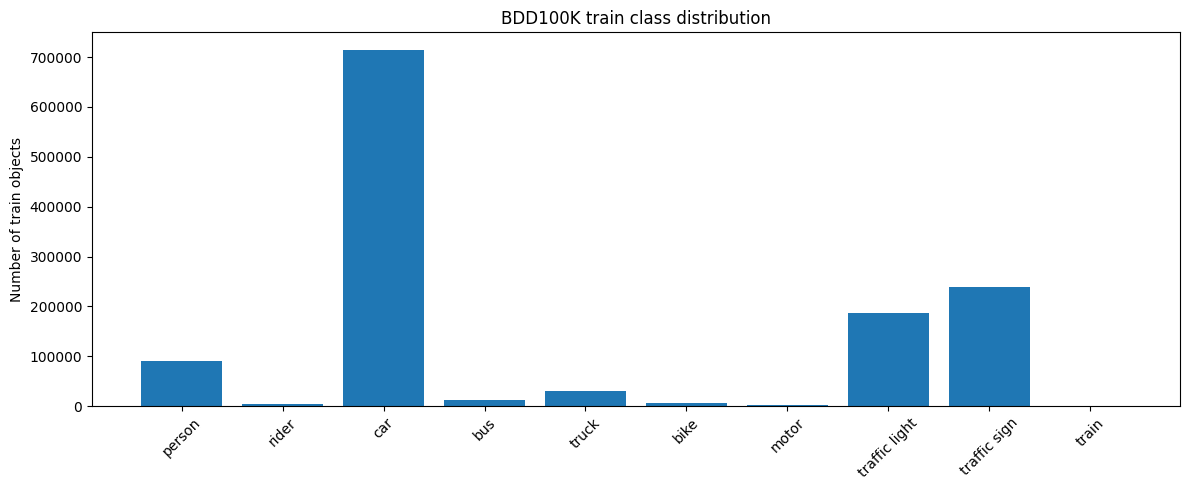

In [12]:
# Thong ke class distribution sau cleaning

def count_classes(label_dir: Path):
    counter = Counter()
    object_per_image = []

    for label_path in tqdm(sorted(label_dir.glob("*.txt"))):
        count_in_file = 0
        with open(label_path, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                class_id = int(float(parts[0]))
                counter[class_id] += 1
                count_in_file += 1
        object_per_image.append(count_in_file)

    return counter, object_per_image


train_class_counts, train_objects_per_image = count_classes(TRAIN_LABELS)
val_class_counts, val_objects_per_image = count_classes(VAL_LABELS)

class_rows = []
for cid in sorted(CLASS_NAMES):
    class_rows.append({
        "class_id": cid,
        "class_name": CLASS_NAMES[cid],
        "train_objects": train_class_counts[cid],
        "val_objects": val_class_counts[cid],
        "is_project_target": cid in TARGET_CLASS_IDS,
    })

class_df = pd.DataFrame(class_rows)
class_df.to_csv(WORK_ROOT / "class_distribution.csv", index=False)
display(class_df)

plt.figure(figsize=(12, 5))
plt.bar(class_df["class_name"], class_df["train_objects"])
plt.xticks(rotation=45)
plt.ylabel("Number of train objects")
plt.title("BDD100K train class distribution")
plt.tight_layout()
plt.show()


  0%|          | 0/2500 [00:00<?, ?it/s]

Sample analyzed: 2500
Top resolutions:


,width,height,count
0,1280,720,2500


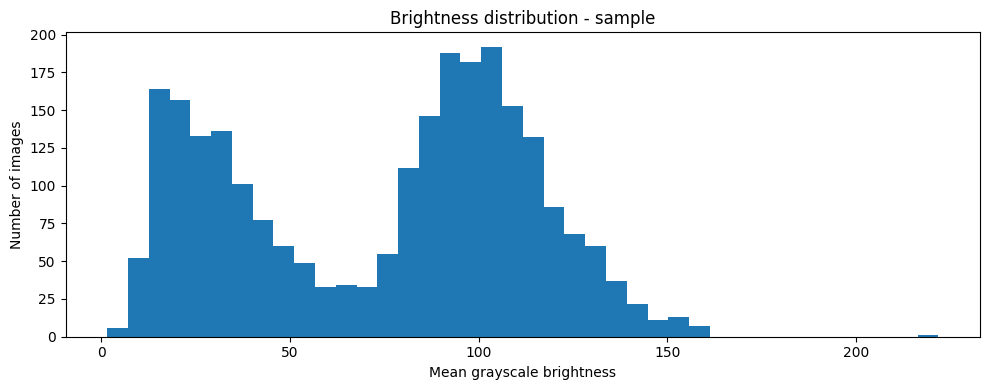

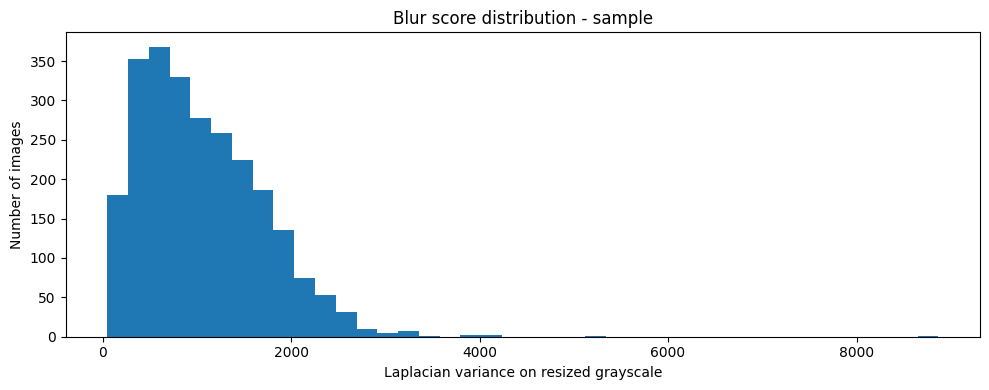

In [13]:
# Phan tich resolution, brightness va blur tren sample de chay nhanh
ANALYSIS_SAMPLE_SIZE = 2500

sample_size = min(ANALYSIS_SAMPLE_SIZE, len(train_images))
analysis_images = random.sample(train_images, sample_size)
quality_rows = []

for image_path in tqdm(analysis_images):
    image = cv2.imread(str(image_path))
    if image is None:
        continue

    h, w = image.shape[:2]
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    brightness = float(gray.mean())

    # Resize chi de tinh blur score nhanh, khong ghi de anh goc
    small_gray = cv2.resize(gray, (320, 180), interpolation=cv2.INTER_AREA)
    blur_score = float(cv2.Laplacian(small_gray, cv2.CV_64F).var())

    quality_rows.append({
        "file": image_path.name,
        "width": w,
        "height": h,
        "brightness": brightness,
        "blur_score": blur_score,
    })

quality_df = pd.DataFrame(quality_rows)
quality_df.to_csv(WORK_ROOT / "image_quality_sample.csv", index=False)

print("Sample analyzed:", len(quality_df))
print("Top resolutions:")
display(quality_df.groupby(["width", "height"]).size().reset_index(name="count").sort_values("count", ascending=False).head(10))

plt.figure(figsize=(10, 4))
plt.hist(quality_df["brightness"], bins=40)
plt.xlabel("Mean grayscale brightness")
plt.ylabel("Number of images")
plt.title("Brightness distribution - sample")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(quality_df["blur_score"], bins=40)
plt.xlabel("Laplacian variance on resized grayscale")
plt.ylabel("Number of images")
plt.title("Blur score distribution - sample")
plt.tight_layout()
plt.show()


## 4. Visual Inspection

Visualize ground-truth bbox sau cleaning. Neu box lech sai nhieu, dung train va kiem tra lai dataset.


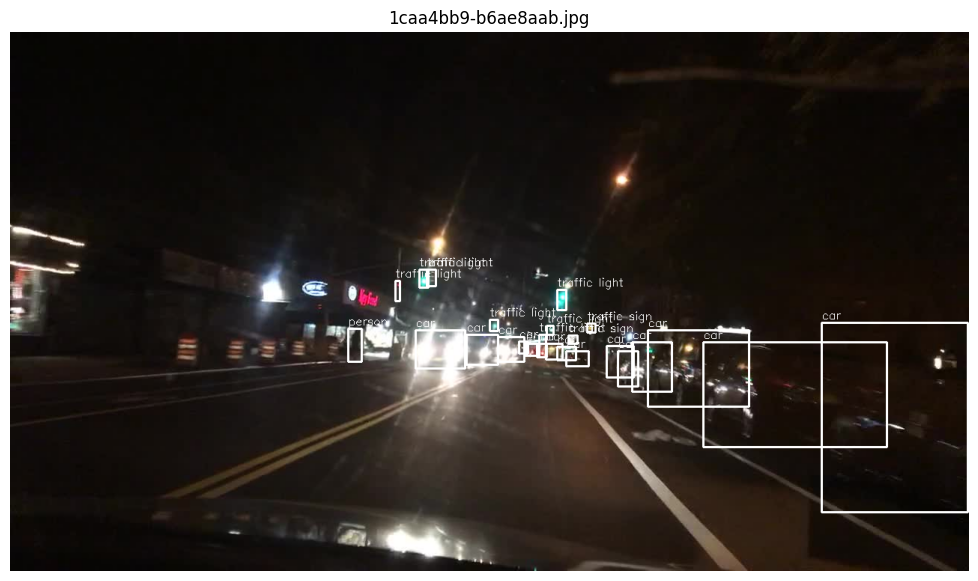

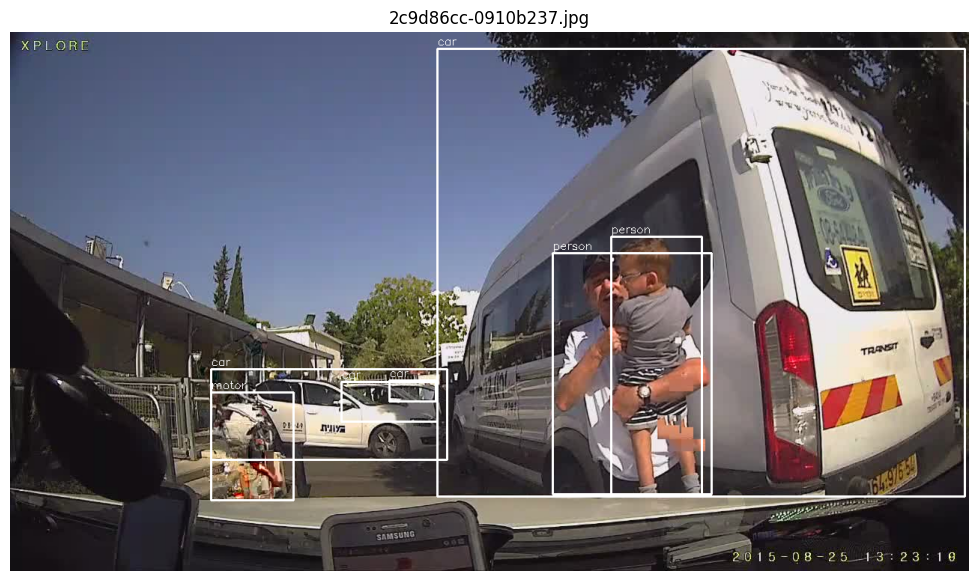

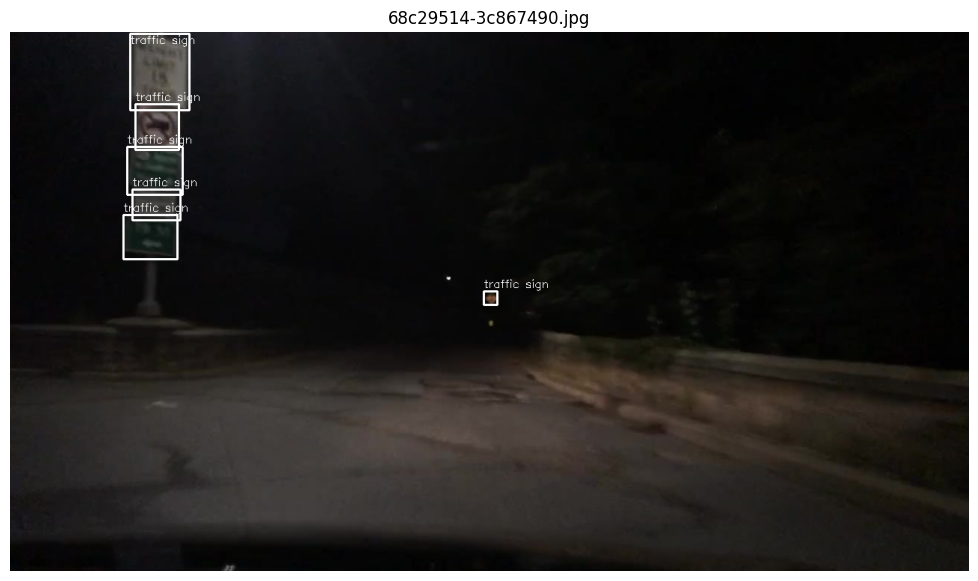

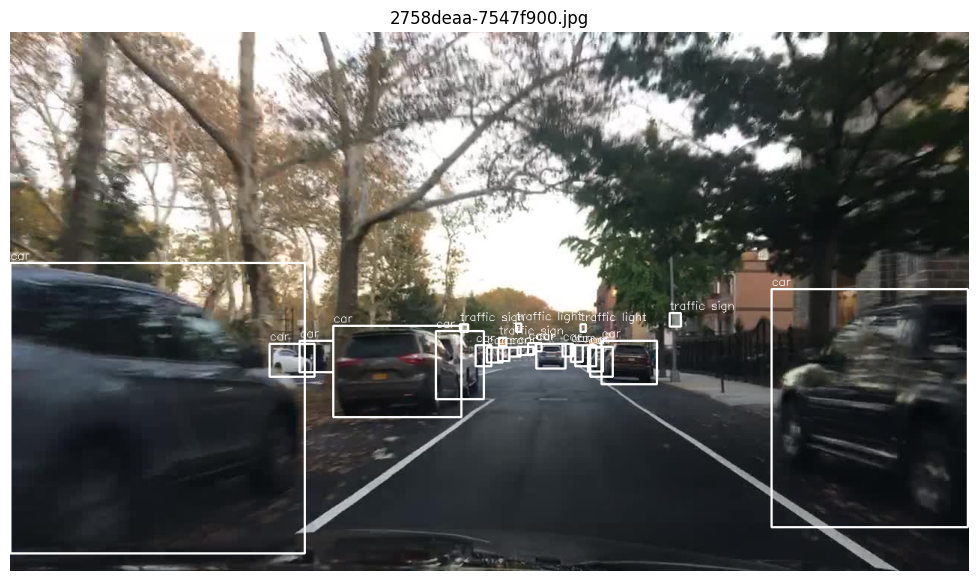

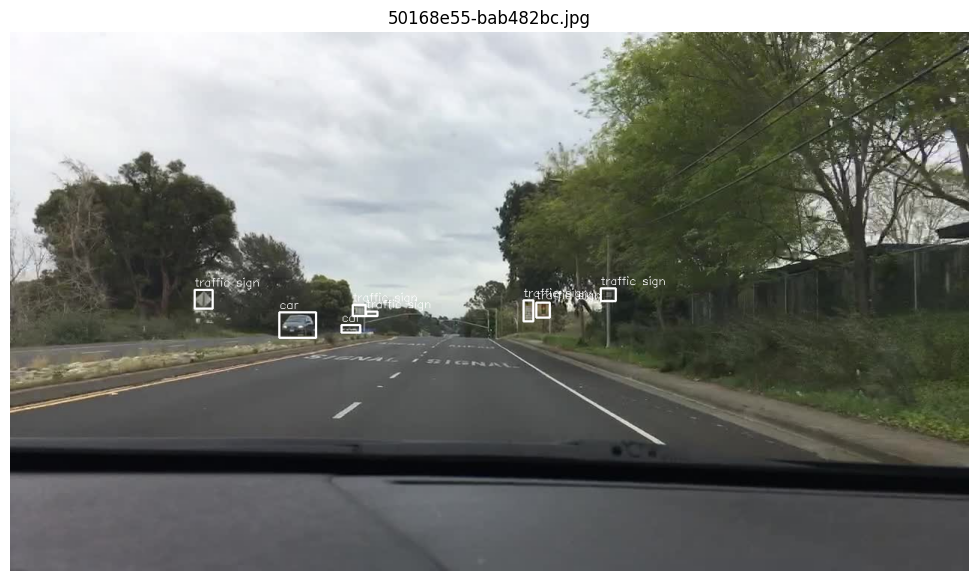

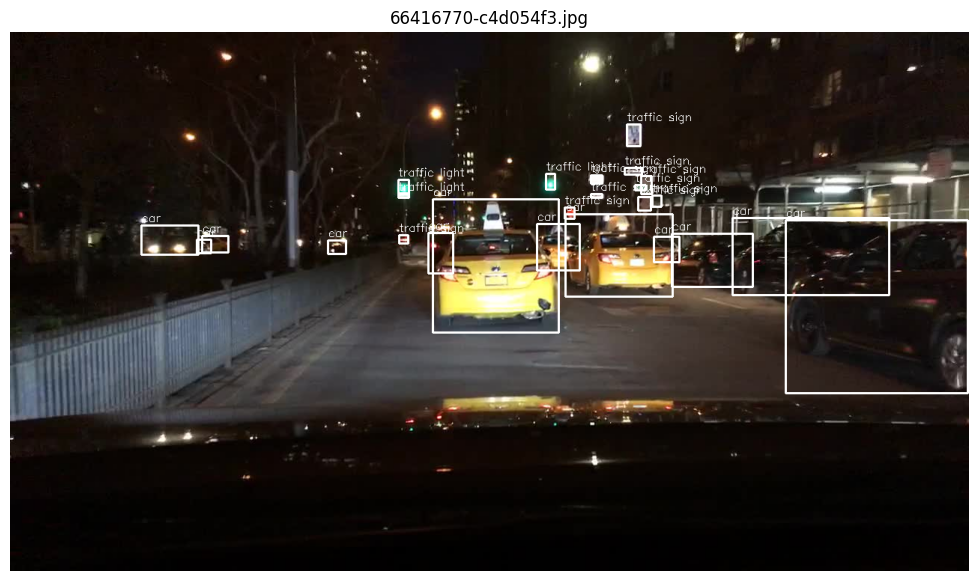

In [14]:
# Ve ground truth bbox tren anh

def draw_ground_truth(image_path: Path, label_dir: Path):
    image = cv2.imread(str(image_path))
    if image is None:
        raise ValueError(f"Khong doc duoc anh: {image_path}")

    h, w = image.shape[:2]
    label_path = label_dir / f"{image_path.stem}.txt"

    if label_path.exists():
        with open(label_path, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue

                cls, xc, yc, bw, bh = map(float, parts)
                cls = int(cls)
                xc *= w
                yc *= h
                bw *= w
                bh *= h

                x1 = int(max(0, xc - bw / 2))
                y1 = int(max(0, yc - bh / 2))
                x2 = int(min(w - 1, xc + bw / 2))
                y2 = int(min(h - 1, yc + bh / 2))

                cv2.rectangle(image, (x1, y1), (x2, y2), (255, 255, 255), 2)
                label = str(CLASS_NAMES.get(cls, cls))
                cv2.putText(image, label, (x1, max(15, y1 - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


VISUAL_SAMPLES = 6
for image_path in random.sample(train_images, min(VISUAL_SAMPLES, len(train_images))):
    annotated = draw_ground_truth(image_path, TRAIN_LABELS)
    plt.figure(figsize=(14, 7))
    plt.imshow(annotated)
    plt.title(image_path.name)
    plt.axis("off")
    plt.show()


## 5. Training-time Preprocessing


In [15]:
# Tao data.yaml sach voi path tuyet doi
CLEAN_YAML = WORK_ROOT / "bdd100k_clean.yaml"

clean_yaml = {
    "path": str(DATA_ROOT.resolve()),
    "train": "train/images",
    "val": "val/images",
    "names": CLASS_NAMES,
}

if TEST_IMAGES.exists():
    clean_yaml["test"] = "test/images"

with open(CLEAN_YAML, "w", encoding="utf-8") as f:
    yaml.safe_dump(clean_yaml, f, sort_keys=False, allow_unicode=True)

print(CLEAN_YAML.read_text(encoding="utf-8"))


path: /kaggle/working/dataset/bdd100k-yolo
train: train/images
val: val/images
names:
  0: person
  1: rider
  2: car
  3: bus
  4: truck
  5: bike
  6: motor
  7: traffic light
  8: traffic sign
  9: train
test: test/images



In [16]:
# Cau hinh training de chay on dinh tren Kaggle GPU
MODEL_NAME = "yolo11m.pt"
IMGSZ = 640
BATCH_SIZE = 32
WORKERS = 4
EPOCHS = 40
PATIENCE = 10
DEVICE = [0, 1] if torch.cuda.device_count() >= 2 else (0 if torch.cuda.is_available() else "cpu")

RUN_SMOKE_TEST = True
RUN_FULL_TRAIN = True

TRAIN_PROJECT = WORK_ROOT / "runs"
TRAIN_NAME = "yolo11m_bdd100k"

train_args = {
    "data": str(CLEAN_YAML),
    "epochs": EPOCHS,
    "imgsz": IMGSZ,
    "batch": BATCH_SIZE,
    "device": DEVICE,
    "workers": WORKERS,
    "patience": PATIENCE,
    "optimizer": "AdamW",
    "amp": True,
    "cache": False,
    "seed": SEED,
    "deterministic": True,
    "project": str(TRAIN_PROJECT),
    "name": TRAIN_NAME,
    "exist_ok": True,
    "plots": True,
    "save": True,
    "verbose": True,
    # Augmentation phu hop traffic scene
    "hsv_h": 0.015,
    "hsv_s": 0.7,
    "hsv_v": 0.4,
    "degrees": 0.0,
    "translate": 0.10,
    "scale": 0.40,
    "shear": 0.0,
    "perspective": 0.0,
    "flipud": 0.0,
    "fliplr": 0.5,
    "mosaic": 1.0,
    "mixup": 0.0,
    "close_mosaic": 5,
}

print(json.dumps({k: str(v) for k, v in train_args.items()}, indent=2))


{
  "data": "/kaggle/working/traffic_training/bdd100k_clean.yaml",
  "epochs": "40",
  "imgsz": "640",
  "batch": "32",
  "device": "[0, 1]",
  "workers": "4",
  "patience": "10",
  "optimizer": "AdamW",
  "amp": "True",
  "cache": "False",
  "seed": "42",
  "deterministic": "True",
  "project": "/kaggle/working/traffic_training/runs",
  "name": "yolo11m_bdd100k",
  "exist_ok": "True",
  "plots": "True",
  "save": "True",
  "verbose": "True",
  "hsv_h": "0.015",
  "hsv_s": "0.7",
  "hsv_v": "0.4",
  "degrees": "0.0",
  "translate": "0.1",
  "scale": "0.4",
  "shear": "0.0",
  "perspective": "0.0",
  "flipud": "0.0",
  "fliplr": "0.5",
  "mosaic": "1.0",
  "mixup": "0.0",
  "close_mosaic": "5"
}


## 6. Smoke Test

Train 1 epoch voi 2% train set, khong validation. 


In [17]:
# Smoke test truoc khi fine-tune full
if RUN_SMOKE_TEST:
    smoke_model = YOLO(MODEL_NAME)
    smoke_result = smoke_model.train(
        data=str(CLEAN_YAML),
        epochs=1,
        fraction=0.02,
        imgsz=IMGSZ,
        batch=BATCH_SIZE,
        device=DEVICE,
        workers=WORKERS,
        amp=True,
        cache=False,
        seed=SEED,
        val=False,
        project=str(TRAIN_PROJECT),
        name="smoke_test",
        exist_ok=True,
        plots=False,
        verbose=True,
    )
    print("Smoke test: DONE")
else:
    print("Smoke test: SKIPPED")


Ultralytics 8.4.137 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                        CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/traffic_training/bdd100k_clean.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=0.02, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(



1 epochs completed in 0.025 hours.
Optimizer stripped from /kaggle/working/traffic_training/runs/smoke_test/weights/last.pt, 40.5MB
Optimizer stripped from /kaggle/working/traffic_training/runs/smoke_test/weights/best.pt, 40.5MB

Validating /kaggle/working/traffic_training/runs/smoke_test/weights/best.pt...
YOLO11m summary (fused): 126 layers, 20,037,742 parameters, 0 gradients, 67.8 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 157/157 3.2it/s 48.5s
                   all      10000     185526          0          0          0          0
                person       3220      13262          0          0          0          0
                 rider        515        649          0          0          0          0
                   car       9879     102506          0          0          0          0
                   bus       1242       1597          0          0          0          0
                 truck       2

## 7. YOLO11 Fine-tuning

Mac dinh dung `yolo11m.pt`


In [18]:
# Fine-tune full dataset
if RUN_FULL_TRAIN:
    if DEVICE == "cpu":
        print("WARNING: Dang train bang CPU. Nen bat GPU Accelerator tren Kaggle.")

    model = YOLO(MODEL_NAME)
    train_result = model.train(**train_args)
    print("Full training: DONE")
else:
    print("Full training: SKIPPED")


Ultralytics 8.4.137 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                        CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=5, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/traffic_training/bdd100k_clean.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=t

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/40      8.09G      1.523     0.9813      1.034        231        640: 100% ━━━━━━━━━━━━ 2188/2188 1.9it/s 19:20
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 157/157 2.7it/s 57.9s
                   all      10000     185526      0.477      0.337      0.346      0.175

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/40      8.07G      1.474     0.9192      1.014        222        640: 100% ━━━━━━━━━━━━ 2188/2188 1.9it/s 19:15
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 157/157 2.7it/s 57.6s
                   all      10000     185526      0.581      0.356      0.369      0.194

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/40       8.1G      1.443      0.881          1        228        640: 100%

## 8. Validation va danh gia



In [19]:
# Tim best.pt va validate tren val set
RUN_DIR = TRAIN_PROJECT / TRAIN_NAME
BEST_MODEL = RUN_DIR / "weights" / "best.pt"
LAST_MODEL = RUN_DIR / "weights" / "last.pt"

print("best.pt:", BEST_MODEL, BEST_MODEL.exists())
print("last.pt:", LAST_MODEL, LAST_MODEL.exists())

if not BEST_MODEL.exists():
    raise FileNotFoundError("Khong tim thay best.pt. Hay chay cell fine-tuning truoc.")

best_model = YOLO(str(BEST_MODEL))

metrics = best_model.val(
    data=str(CLEAN_YAML),
    split="val",
    imgsz=IMGSZ,
    batch=BATCH_SIZE,
    device=DEVICE,
    workers=WORKERS,
    plots=True,
    project=str(WORK_ROOT / "validation"),
    name="best_val",
    exist_ok=True,
    verbose=True,
)


best.pt: /kaggle/working/traffic_training/runs/yolo11m_bdd100k/weights/best.pt True
last.pt: /kaggle/working/traffic_training/runs/yolo11m_bdd100k/weights/last.pt True
Ultralytics 8.4.137 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                        CUDA:1 (Tesla T4, 14912MiB)
YOLO11m summary (fused): 126 layers, 20,037,742 parameters, 0 gradients, 67.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1527.2±715.1 MB/s, size: 65.8 KB)
val: Scanning /kaggle/working/dataset/bdd100k-yolo/val/labels.cache... 10000 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10000/10000 3.2Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 313/313 1.4it/s 3:48
                   all      10000     185526      0.732      0.471      0.523       0.29
                person       3220      13262      0.745      0.556       0.63      0.316
                 rider        515

In [20]:
# Tong hop overall metric va speed
speed = dict(metrics.speed)
pre_ms = float(speed.get("preprocess", 0.0))
inf_ms = float(speed.get("inference", 0.0))
post_ms = float(speed.get("postprocess", 0.0))
model_pipeline_ms = pre_ms + inf_ms + post_ms

summary = {
    "model": str(BEST_MODEL),
    "precision": float(metrics.box.mp),
    "recall": float(metrics.box.mr),
    "map50": float(metrics.box.map50),
    "map50_95": float(metrics.box.map),
    "preprocess_ms_per_image": pre_ms,
    "inference_ms_per_image": inf_ms,
    "postprocess_ms_per_image": post_ms,
    "inference_fps_approx": float(1000.0 / inf_ms) if inf_ms > 0 else None,
    "model_pipeline_fps_approx": float(1000.0 / model_pipeline_ms) if model_pipeline_ms > 0 else None,
}

print(json.dumps(summary, indent=2))
with open(WORK_ROOT / "validation_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)


{
  "model": "/kaggle/working/traffic_training/runs/yolo11m_bdd100k/weights/best.pt",
  "precision": 0.7317143949884842,
  "recall": 0.47064864595155687,
  "map50": 0.5227476150823106,
  "map50_95": 0.29006058654429434,
  "preprocess_ms_per_image": 0.5274878308962798,
  "inference_ms_per_image": 18.397187118790317,
  "postprocess_ms_per_image": 0.9089382802019826,
  "inference_fps_approx": 54.356135725696404,
  "model_pipeline_fps_approx": 50.41945652610761
}


In [21]:
# Metric theo tung class va rieng 4 class project
box_metric = metrics.box
p_arr = np.asarray(box_metric.p, dtype=float)
r_arr = np.asarray(box_metric.r, dtype=float)
ap50_arr = np.asarray(box_metric.ap50, dtype=float)
ap_arr = np.asarray(box_metric.ap, dtype=float)

try:
    ap_class_ids = [int(x) for x in np.asarray(box_metric.ap_class_index).tolist()]
except Exception:
    ap_class_ids = list(range(len(p_arr)))

per_class_rows = []
for idx, class_id in enumerate(ap_class_ids):
    if idx >= len(p_arr):
        continue
    map50_95_class = float(ap_arr[idx].mean()) if ap_arr.ndim == 2 else float("nan")
    per_class_rows.append({
        "class_id": class_id,
        "class_name": CLASS_NAMES.get(class_id, str(class_id)),
        "precision": float(p_arr[idx]),
        "recall": float(r_arr[idx]),
        "map50": float(ap50_arr[idx]),
        "map50_95": map50_95_class,
        "is_project_target": class_id in TARGET_CLASS_IDS,
    })

per_class_df = pd.DataFrame(per_class_rows)
per_class_df.to_csv(WORK_ROOT / "per_class_metrics.csv", index=False)
display(per_class_df)

project_metric_df = per_class_df[per_class_df["is_project_target"]].copy()
print("Project target metrics:")
display(project_metric_df)

if len(project_metric_df):
    target_summary = {
        "mean_precision_4_classes": float(project_metric_df["precision"].mean()),
        "mean_recall_4_classes": float(project_metric_df["recall"].mean()),
        "mean_map50_4_classes": float(project_metric_df["map50"].mean()),
        "mean_map50_95_4_classes": float(project_metric_df["map50_95"].mean()),
    }
    print(json.dumps(target_summary, indent=2))
    with open(WORK_ROOT / "project_4class_summary.json", "w", encoding="utf-8") as f:
        json.dump(target_summary, f, indent=2)


,class_id,class_name,precision,recall,map50,map50_95,is_project_target
0,0,person,0.744794,0.555648,0.630382,NaN,False
1,1,rider,0.651966,0.388290,0.424936,NaN,False
2,2,car,0.790839,0.735908,0.787430,NaN,True
3,3,bus,0.664652,0.500313,0.568414,NaN,True
4,4,truck,0.686490,0.531213,0.610590,NaN,True
5,5,bike,0.614375,0.397219,0.437428,NaN,False
6,6,motor,0.761699,0.311154,0.435171,NaN,True
7,7,traffic light,0.685266,0.648800,0.649381,NaN,False
8,8,traffic sign,0.717062,0.637940,0.683743,NaN,False
9,9,train,1.000000,0.000000,0.000000,NaN,False


Project target metrics:


,class_id,class_name,precision,recall,map50,map50_95,is_project_target
2,2,car,0.790839,0.735908,0.787430,NaN,True
3,3,bus,0.664652,0.500313,0.568414,NaN,True
4,4,truck,0.686490,0.531213,0.610590,NaN,True
6,6,motor,0.761699,0.311154,0.435171,NaN,True


{
  "mean_precision_4_classes": 0.7259203592222045,
  "mean_recall_4_classes": 0.51964719121654,
  "mean_map50_4_classes": 0.6004013366499196,
  "mean_map50_95_4_classes": NaN
}


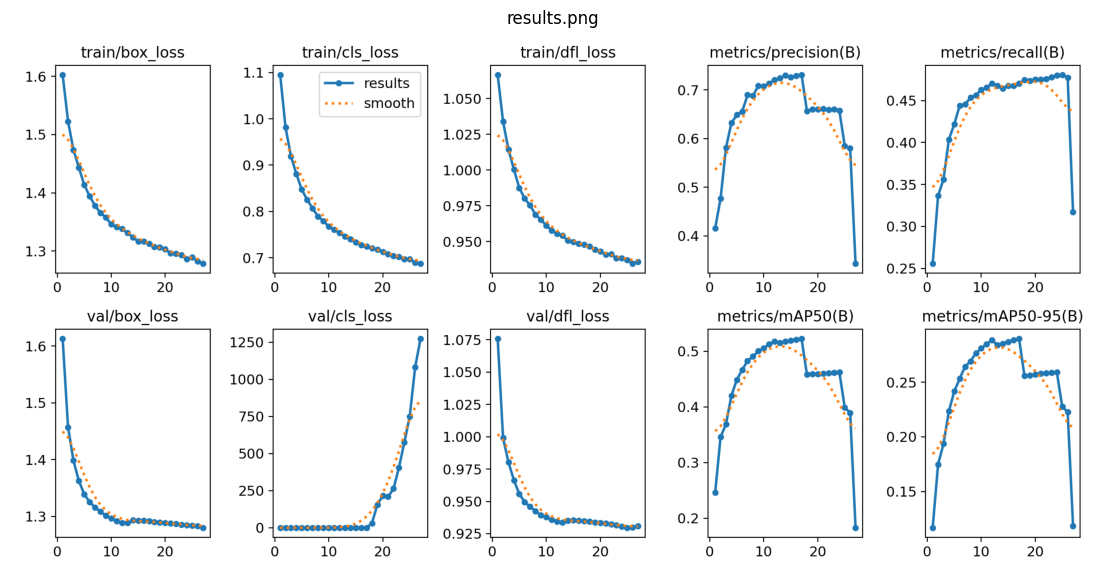

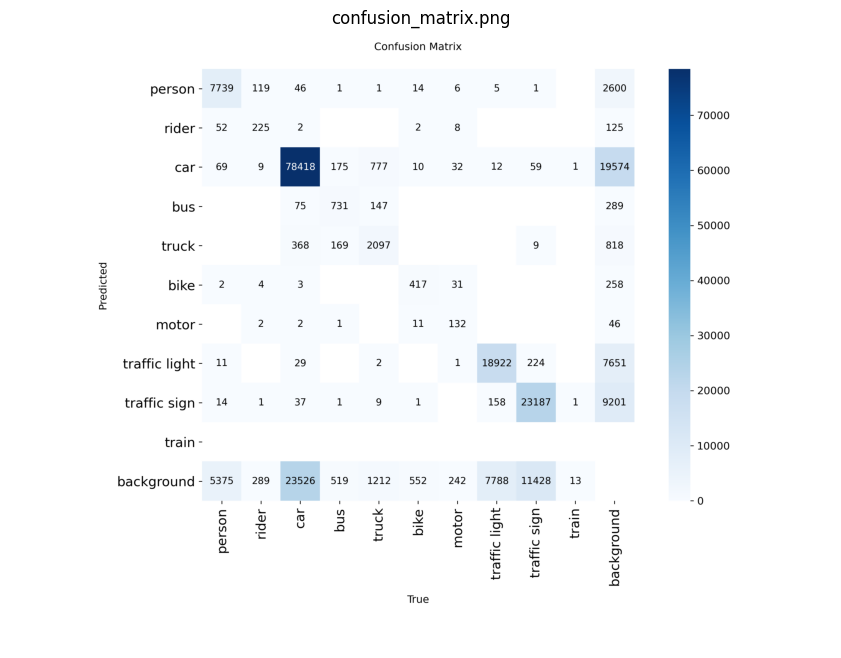

In [22]:
# Hien thi learning curve va confusion matrix neu co
results_png = RUN_DIR / "results.png"
val_dir = WORK_ROOT / "validation" / "best_val"
confusion_png = val_dir / "confusion_matrix.png"

for plot_path in [results_png, confusion_png]:
    if plot_path.exists():
        image = cv2.imread(str(plot_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(14, 8))
        plt.imshow(image)
        plt.title(plot_path.name)
        plt.axis("off")
        plt.show()
    else:
        print("Khong tim thay:", plot_path)
